In [6]:
import numpy as np

perch_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0]
     )

print(len(perch_length), len(perch_weight))

56 56


In [7]:
from sklearn.model_selection import train_test_split


train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state = 42)

In [8]:
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)


In [9]:
from sklearn.neighbors import KNeighborsRegressor
import sklearn
sklearn.set_config(display='text')



knr = KNeighborsRegressor(n_neighbors = 3)

knr.fit(train_input, train_target)

KNeighborsRegressor(n_neighbors=3)

In [10]:
distances, indexes = knr.kneighbors([[100]])

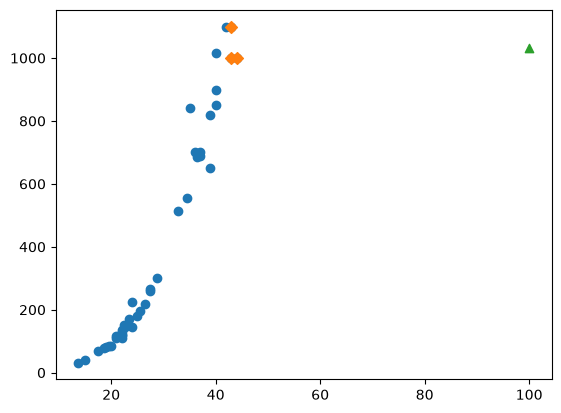

In [11]:
import matplotlib.pyplot as plt

plt.scatter(train_input, train_target)
plt.scatter(train_input[indexes], train_target[indexes], marker = 'D')

plt.scatter(100, 1033, marker =  '^')

plt.show()

In [12]:
from sklearn.linear_model  import LinearRegression

lr = LinearRegression()

lr.fit(train_input, train_target)

print(lr.predict([[50]]))


[1241.83860323]


In [13]:
print(lr.coef_, lr.intercept_)

[39.01714496] -709.0186449535474


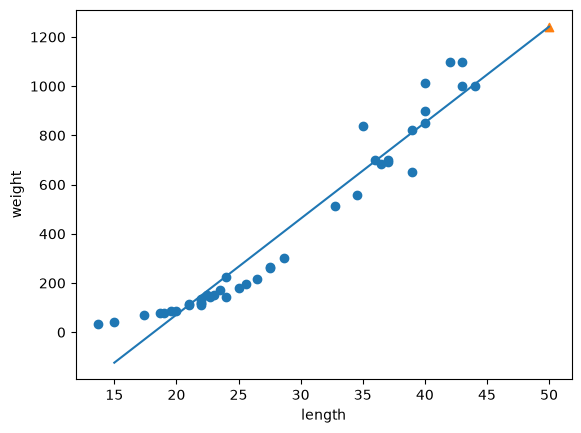

In [15]:
plt.scatter(train_input, train_target)

plt.plot([15, 50], [15*lr.coef_ + lr.intercept_, 50*lr.coef_ +lr.intercept_])

plt.scatter(50, 1241.8, marker="^")
plt.xlabel("length")
plt.ylabel("weight")
plt.show()


In [16]:
print(lr.score(train_input, train_target))
print(lr.score(test_input, test_target))


0.9398463339976041
0.824750312331356


In [25]:
train_poly = np.column_stack((train_input, train_input**2))
test_poly = np.column_stack(( test_input, test_input**2))


In [26]:
print(train_poly.shape)
print(test_poly.shape)

(42, 2)
(14, 2)


In [28]:
lr = LinearRegression()

lr.fit(train_poly, train_target)

print(lr.predict([[ 50, 50**2]]))


[1573.98423528]


In [29]:
print(lr.coef_, lr.intercept_)

[-21.55792498   1.01433211] 116.05021078278395


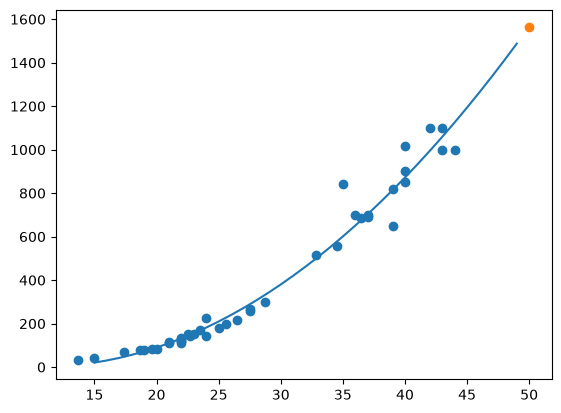

In [31]:
point = np.arange(15, 50)

plt.scatter(train_input, train_target)

plt.plot(point, 1.01*point**2 + (-21.5)*point + 116.0)

plt.scatter(50, 1.01*50**2 + (-21.5)*50 + 116.0)

In [32]:
print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))


0.9706807451768623
0.9775935108325123
